In [1]:
%matplotlib inline
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from astro_plot_utils import load_table, extract_columns

In [2]:
PATH_Q1  = "/data/astro/scratch/vdeshpan/data/Q1_general.parquet"
PATH_FS2 = "/data/astro/scratch/vdeshpan/data/FS2_general.parquet"

NSIDE = 64
RA_COL_Q1  = "right_ascension"
DEC_COL_Q1 = "declination"
RA_COL_FS2  = "ra_gal"
DEC_COL_FS2 = "dec_gal"

In [3]:
df_q1  = load_table(PATH_Q1)
df_fs2 = load_table(PATH_FS2)

coords_q1 = extract_columns(df_q1, [RA_COL_Q1, DEC_COL_Q1], dropna=True)
ra_q1  = coords_q1[RA_COL_Q1]
dec_q1 = coords_q1[DEC_COL_Q1]

coords_fs2 = extract_columns(df_fs2, [RA_COL_FS2, DEC_COL_FS2], dropna=True)
ra_fs2  = coords_fs2[RA_COL_FS2]
dec_fs2 = coords_fs2[DEC_COL_FS2]

print(f"Q1  loaded: {len(ra_q1):,} sources")
print(f"FS2 loaded: {len(ra_fs2):,} sources")

Q1  loaded: 29,643,313 sources
FS2 loaded: 18,890,277 sources


In [4]:
theta_q1 = np.radians(90 - dec_q1)
phi_q1   = np.radians(ra_q1)
pix_q1   = hp.ang2pix(NSIDE, theta_q1, phi_q1, nest=False)

theta_fs2 = np.radians(90 - dec_fs2)
phi_fs2   = np.radians(ra_fs2)
pix_fs2   = hp.ang2pix(NSIDE, theta_fs2, phi_fs2, nest=False)

unique_pix_q1  = np.unique(pix_q1)
unique_pix_fs2 = np.unique(pix_fs2)

npix = hp.nside2npix(NSIDE)
area_per_pix_deg2 = (4 * np.pi / npix) * (180 / np.pi)**2

print(f"Q1  → {len(unique_pix_q1):,} unique pixels  → {len(unique_pix_q1) * area_per_pix_deg2:.1f} deg²")
print(f"FS2 → {len(unique_pix_fs2):,} unique pixels  → {len(unique_pix_fs2) * area_per_pix_deg2:.1f} deg²")

Q1  → 130 unique pixels  → 109.1 deg²
FS2 → 6,318 unique pixels  → 5302.7 deg²


/tmp/ipykernel_459/1643869026.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


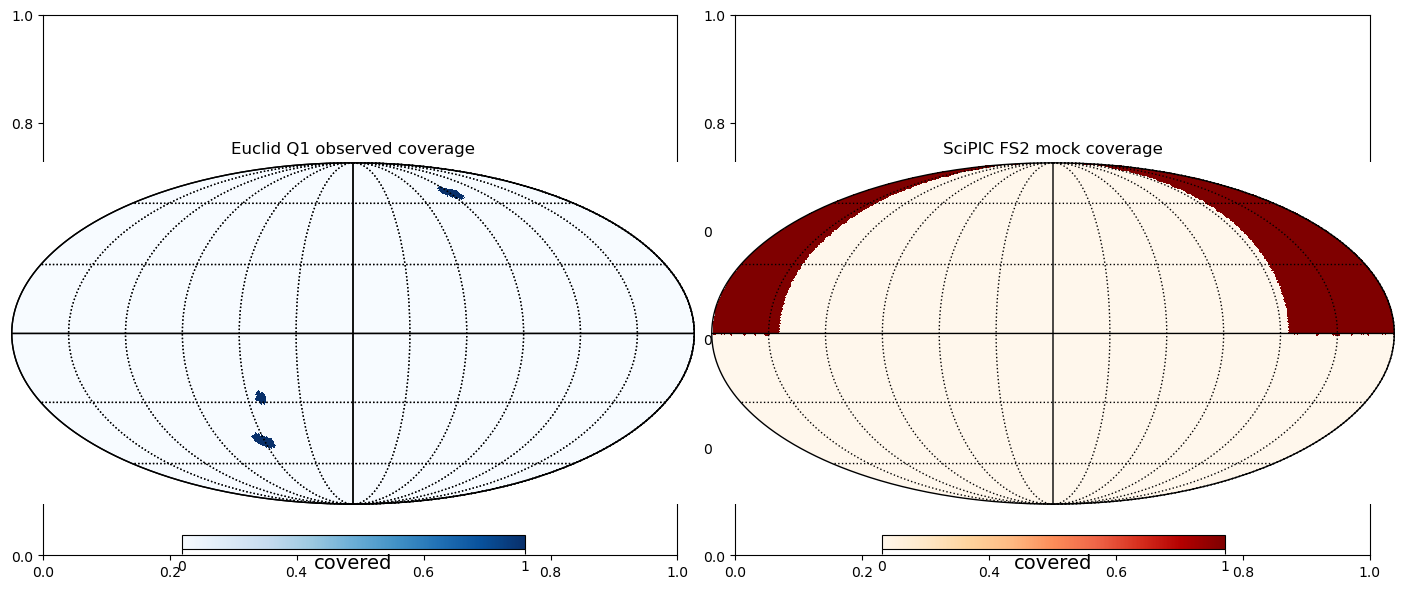

In [5]:
def make_coverage_map(pixels, nside):
    m = np.zeros(hp.nside2npix(nside))
    m[np.unique(pixels)] = 1.0
    return m

map_q1  = make_coverage_map(pix_q1,  NSIDE)
map_fs2 = make_coverage_map(pix_fs2, NSIDE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hp.mollview(map_q1,  title="Euclid Q1 observed coverage",  cmap="Blues",  nest=False, fig=fig, sub=121, unit="covered")
hp.graticule()

hp.mollview(map_fs2, title="SciPIC FS2 mock coverage",     cmap="OrRd",   nest=False, fig=fig, sub=122, unit="covered")
hp.graticule()

plt.tight_layout()
plt.show()